# Data exploration and loading
Simple script to convert the NHANES data to parquet files for easier analysis later.

In [34]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import pyreadstat
import ambient_light_epilepsy.nhanes as nhn  # adjust if your import path differs
import time

In [2]:
# Data paths
data_dir = Path("W:/projects/ambient_light_epilepsy_analysis/data/H")

# Find all XPT files
xpt_files = sorted(data_dir.glob("*.xpt"))

print("XPT files in directory:")
display(xpt_files)

print(f"Found {len(xpt_files)} XPT files")

# Loop through and convert
for xpt_path in xpt_files:
    parquet_path = nhn.xpt_to_parquet(
        xpt_path,
        parquet_dir=data_dir,
        overwrite=False
    )
    print(f"✔ Converted: {xpt_path.name} → {parquet_path.name}")
    

XPT files in directory:


[WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/H/DEMO_H.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/H/DPQ_H.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/H/OCQ_H.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/H/PAXHD_H.xpt'),
 WindowsPath('W:/projects/ambient_light_epilepsy_analysis/data/H/RXQ_RX_H.xpt')]

Found 5 XPT files
✔ Converted: DEMO_H.xpt → DEMO_H.parquet
✔ Converted: DPQ_H.xpt → DPQ_H.parquet
✔ Converted: OCQ_H.xpt → OCQ_H.parquet
✔ Converted: PAXHD_H.xpt → PAXHD_H.parquet
✔ Converted: RXQ_RX_H.xpt → RXQ_RX_H.parquet


## Load the activity data
This is expensive due to the size, so pyarrow needs to be used

In [6]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/G/PAXMIN_G.parquet")
pf = pq.ParquetFile(p)
pf.schema


required group field_id=-1 schema {
  optional double field_id=-1 SEQN;
  optional binary field_id=-1 PAXDAYM (String);
  optional binary field_id=-1 PAXDAYWM (String);
  optional double field_id=-1 PAXSSNMP;
  optional double field_id=-1 PAXTSM;
  optional double field_id=-1 PAXAISMM;
  optional double field_id=-1 PAXMTSM;
  optional double field_id=-1 PAXMXM;
  optional double field_id=-1 PAXMYM;
  optional double field_id=-1 PAXMZM;
  optional binary field_id=-1 PAXPREDM (String);
  optional binary field_id=-1 PAXTRANM (String);
  optional double field_id=-1 PAXLXMM;
  optional double field_id=-1 PAXLXSDM;
  optional double field_id=-1 PAXQFM;
  optional binary field_id=-1 PAXFLGSM (String);
}

In [5]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/G/PAXHD_G.parquet")
df = pd.read_parquet(p)
df.columns


Index(['SEQN', 'PAXSTS', 'PAXSENID', 'PAXFDAY', 'PAXLDAY', 'PAXFTIME',
       'PAXETLDY', 'PAXHAND', 'PAXORENT'],
      dtype='object')

In [6]:
df

,SEQN,PAXSTS,PAXSENID,PAXFDAY,PAXLDAY,PAXFTIME,PAXETLDY,PAXHAND,PAXORENT
0,62161.0,1.0,NEO1G62402505,7,9,12:30:00,12:39:29,1,1
1,62163.0,1.0,NEO1G78016948,7,9,17:30:00,17:38:59,1,1
2,62164.0,1.0,NEO1G14270410,1,9,12:30:00,12:38:58,1,1
3,62165.0,1.0,NEO1G81122824,7,9,12:30:00,12:39:29,1,1
4,62166.0,1.0,NEO1G46206291,7,5,12:30:00,10:38:00,1,1
...,...,...,...,...,...,...,...,...,...
7816,71912.0,2.0,,,,,,,
7817,71913.0,1.0,NEO1G48864360,3,9,16:30:00,16:38:58,1,1
7818,71914.0,1.0,NEO1G67822383,6,9,12:30:00,12:39:23,1,1
7819,71915.0,1.0,NEO1G58315384,2,9,12:30:00,12:38:57,1,1


## Load the LUX data
This is also expensive and PyArrow is used. Note that LUX data has been down sampled to 5min (from 1s) for analysis on local PC.

In [3]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_H/parquet_5min/SEQN_73557_5min.parquet")
t0 = time.time()
pf = pq.ParquetFile(p)
df = pf.read(columns=["timestamp", "mean_lux"]).to_pandas()
print(f"Time taken to load parquet with pyarrow: {round(time.time()-t0,3)} s")



Time taken to load parquet with pyarrow: 1.526 s


<Axes: >

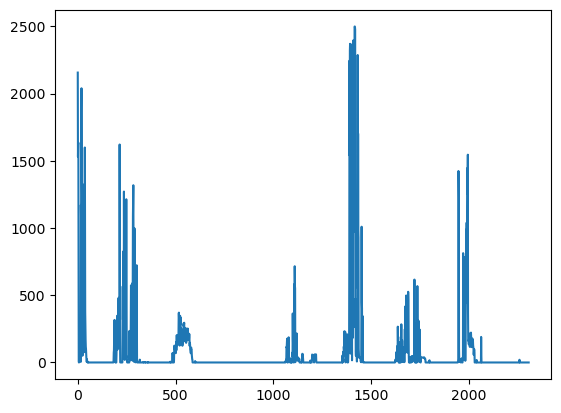

In [4]:
df['mean_lux'].plot()

## Load the medical conditions table

In [9]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/G/MCQ_G.parquet")
df = pd.read_parquet(p)
df.columns

Index(['SEQN', 'MCQ010', 'MCQ025', 'MCQ035', 'MCQ040', 'MCQ050', 'MCQ051',
       'MCQ053', 'MCQ070', 'MCQ075', 'MCQ080', 'MCQ082', 'MCQ084', 'MCQ086',
       'MCQ092', 'MCD093', 'MCQ140', 'MCQ149', 'MCQ160A', 'MCQ180A', 'MCQ195',
       'MCQ160N', 'MCQ180N', 'MCQ160B', 'MCQ180B', 'MCQ160C', 'MCQ180C',
       'MCQ160D', 'MCQ180D', 'MCQ160E', 'MCQ180E', 'MCQ160F', 'MCQ180F',
       'MCQ160G', 'MCQ180G', 'MCQ160M', 'MCQ170M', 'MCQ180M', 'MCQ160K',
       'MCQ170K', 'MCQ180K', 'MCQ160L', 'MCQ170L', 'MCQ180L', 'MCQ220',
       'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D', 'MCQ240A', 'MCQ240AA',
       'MCQ240B', 'MCQ240BB', 'MCQ240C', 'MCQ240CC', 'MCQ240D', 'MCQ240DD',
       'MCQ240DK', 'MCQ240E', 'MCQ240F', 'MCQ240G', 'MCQ240H', 'MCQ240I',
       'MCQ240J', 'MCQ240K', 'MCQ240L', 'MCQ240M', 'MCQ240N', 'MCQ240O',
       'MCQ240P', 'MCQ240Q', 'MCQ240R', 'MCQ240S', 'MCQ240T', 'MCQ240U',
       'MCQ240V', 'MCQ240W', 'MCQ240X', 'MCQ240Y', 'MCQ240Z', 'MCQ300A',
       'MCQ300B', 'MCQ300C', 'MCQ36

In [10]:
df

,SEQN,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ051,MCQ053,MCQ070,MCQ075,...,MCQ300C,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380
0,62161.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,NaN
1,62162.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62163.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,62164.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,NaN
4,62165.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9359,71912.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN
9360,71913.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,NaN,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,NaN
9361,71914.0,1.0,3.0,1.0,1.0,2.0,1.0,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9362,71915.0,2.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,...,1.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,0.0


## Load the prescription meds table

In [14]:
# This works for G
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/G/RXQ_RX_G.parquet")
df = pd.read_parquet(p)
df.columns

Index(['SEQN', 'RXDUSE', 'RXDDRUG', 'RXDDRGID', 'RXQSEEN', 'RXDDAYS',
       'RXDCOUNT'],
      dtype='object')

In [13]:
# This method must be used for H
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/H/RXQ_RX_H.parquet")
table = pq.read_table(p)

# Get all column names except the bad one
good_cols = [c for c in table.column_names if c != "RXDRSD1"]

# Select only good columns
table_subset = table.select(good_cols)

# Convert to pandas
df = table_subset.to_pandas()

df

,SEQN,RXDUSE,RXDDRUG,RXDDRGID,RXQSEEN,RXDDAYS,RXDRSC1,RXDRSC2,RXDRSC3,RXDRSD2,RXDRSD3,RXDCOUNT
0,73557.0,1.0,99999,,NaN,NaN,,,,,,2.0
1,73557.0,1.0,INSULIN,d00262,2.0,1460.0,E11,,,,,2.0
2,73558.0,1.0,GABAPENTIN,d03182,1.0,243.0,G25.81,,,,,4.0
3,73558.0,1.0,INSULIN GLARGINE,d04538,1.0,365.0,E11,,,,,4.0
4,73558.0,1.0,OLMESARTAN,d04801,1.0,14.0,E11.2,,,,,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
20189,83727.0,2.0,,,NaN,NaN,,,,,,NaN
20190,83728.0,2.0,,,NaN,NaN,,,,,,NaN
20191,83729.0,2.0,,,NaN,NaN,,,,,,NaN
20192,83730.0,2.0,,,NaN,NaN,,,,,,NaN


## Load the demographics table

In [10]:
p = Path("W:/projects/ambient_light_epilepsy_analysis/data/H/DEMO_H.parquet")
df = pd.read_parquet(p)
df.columns

Index(['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN',
       'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC',
       'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL',
       'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY',
       'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ',
       'DMDFMSIZ', 'DMDHHSZA', 'DMDHHSZB', 'DMDHHSZE', 'DMDHRGND', 'DMDHRAGE',
       'DMDHRBR4', 'DMDHREDU', 'DMDHRMAR', 'DMDHSEDU', 'WTINT2YR', 'WTMEC2YR',
       'SDMVPSU', 'SDMVSTRA', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR'],
      dtype='object')

In [11]:
df

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557.0,8.0,2.0,1.0,69.0,NaN,4.0,4.0,1.0,NaN,...,3.0,4.0,NaN,13281.237386,13481.042095,1.0,112.0,4.0,4.0,0.84
1,73558.0,8.0,2.0,1.0,54.0,NaN,3.0,3.0,1.0,NaN,...,3.0,1.0,1.0,23682.057386,24471.769625,1.0,108.0,7.0,7.0,1.78
2,73559.0,8.0,2.0,1.0,72.0,NaN,3.0,3.0,2.0,NaN,...,4.0,1.0,3.0,57214.803319,57193.285376,1.0,109.0,10.0,10.0,4.51
3,73560.0,8.0,2.0,1.0,9.0,NaN,3.0,3.0,1.0,119.0,...,3.0,1.0,4.0,55201.178592,55766.512438,2.0,109.0,9.0,9.0,2.52
4,73561.0,8.0,2.0,2.0,73.0,NaN,3.0,3.0,1.0,NaN,...,5.0,1.0,5.0,63709.667069,65541.871229,2.0,116.0,15.0,15.0,5.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10170,83727.0,8.0,2.0,1.0,26.0,NaN,2.0,2.0,2.0,NaN,...,3.0,NaN,NaN,27141.631824,28115.568221,1.0,104.0,77.0,77.0,NaN
10171,83728.0,8.0,2.0,2.0,2.0,24.0,1.0,1.0,2.0,24.0,...,3.0,1.0,3.0,15274.475360,16512.138781,1.0,107.0,8.0,8.0,1.95
10172,83729.0,8.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,5.0,3.0,NaN,24122.248900,26902.344381,1.0,104.0,7.0,7.0,3.66
10173,83730.0,8.0,2.0,1.0,7.0,NaN,2.0,2.0,1.0,84.0,...,4.0,1.0,3.0,25521.878546,26686.025573,2.0,109.0,6.0,6.0,1.05


## Load the mental health table

In [39]:
def load_dpq(year, dropna=True):

    p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/{year}/dpq_{year}.parquet")

    phq_cols = [
        "DPQ010","DPQ020","DPQ030",
        "DPQ040","DPQ050","DPQ060",
        "DPQ070","DPQ080","DPQ090"
    ]

    df = pd.read_parquet(p, columns=["SEQN"] + phq_cols)
    df = df.set_index("SEQN")

    if dropna == True:
        df = df.dropna()


    df["phq9_total"] = df.sum(axis=1)
    df["depressed"] = df["phq9_total"] >= 10

    return df


df = load_dpq("H")

In [40]:
df["depressed"].sum()/len(df)

np.float64(0.0977192657148155)

<Axes: >

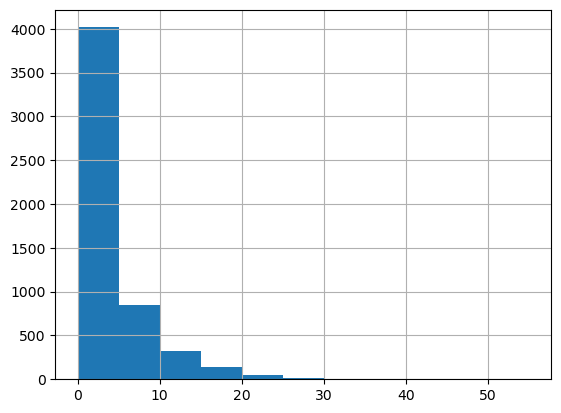

In [41]:
df["phq9_total"].hist(bins=np.arange(0, 60, 5))

In [32]:
df["phq9_total"].describe()

count    4944.000000
mean        3.236044
std         4.699885
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        63.000000
Name: phq9_total, dtype: float64

## Load the occupation table

In [23]:
def load_employment(year):

    p = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/{year}/OCQ_{year}.parquet")

    cols = ["SEQN", "OCD150"]

    df = pd.read_parquet(p, columns=cols)
    df = df.set_index("SEQN")

    df["employed"] = df["OCD150"].isin([1,2])

    return df


load_employment("H")

,OCD150,employed
SEQN,,
73557.0,4.0,False
73558.0,1.0,True
73559.0,4.0,False
73561.0,4.0,False
73562.0,1.0,True
...,...,...
83723.0,1.0,True
83724.0,4.0,False
83726.0,1.0,True
